# Clase 36 - Notebook 4 - Algoritmos de toma de decisiones multicriterio (MCDM) para seleccionar una solución del frente de Pareto.

Existen divesos algoritmos MCDM que permiten seleccionar soluciones cuando existen más de un criterio. Para más detalle se puede revisar el paper de [Wang et al. 2017](https://pubs.acs.org/doi/10.1021/acs.iecr.6b03453).

En este notebook implementamos las siguientes estrategias para toma de decisiones multicriterio, considerando tres combinaciones distintas de pesos:

- TOPSIS sobre NSGA-II
- Función de deseabilidad

# 04 — Toma de decisiones (TOPSIS + DFA)
Usa los **mismos pesos** para ambos enfoques y marca las soluciones sobre el frente NSGA-II.

Algoritmo de solución

In [2]:
# --- Preámbulo Universal para Google Colab y Entornos Locales ---
import os, sys

if 'google.colab' in sys.modules:
    REPO_DIR = '/content/DAII-SprayDrying'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/felipehuerta17/DAII-SprayDrying.git {REPO_DIR}
    os.chdir(REPO_DIR)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    %pip install -q numpy scipy pandas matplotlib pymoo casadi


Gráficos

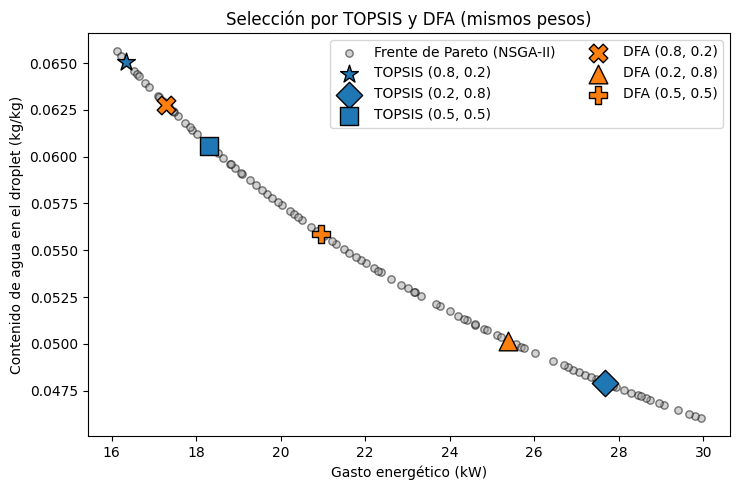

In [3]:
# Figura combinada
plt.figure(figsize=(7.5,5.0))
plt.scatter(F[:,0],F[:,1],s=28,color="0.65",edgecolor="black",alpha=0.5,label="Frente de Pareto (NSGA-II)")
for pt,m,lab in zip(y_TOPSIS, ["*","D","s"], [f"TOPSIS {tuple(w0)}",f"TOPSIS {tuple(w1)}",f"TOPSIS {tuple(w2)}"]):
    plt.scatter([pt[0]],[pt[1]],s=180,marker=m,edgecolor="black",color="#1f77b4",label=lab)
for pt,m,lab in zip(y_DFA2, ["X","^","P"], [f"DFA {tuple(w0)}",f"DFA {tuple(w1)}",f"DFA {tuple(w2)}"]):
    plt.scatter([pt[0]],[pt[1]],s=180,marker=m,edgecolor="black",color="#ff7f0e",label=lab)
plt.xlabel("Gasto energético (kW)"); plt.ylabel("Contenido de agua en el droplet (kg/kg)")
plt.title("Selección por TOPSIS y DFA (mismos pesos)"); plt.legend(ncol=2); plt.tight_layout()
stamp=time.strftime("%Y%m%d-%H%M%S"); plt.savefig(f"./outputs/topsis_vs_dfa_{stamp}.png",dpi=200); plt.savefig(f"./outputs/topsis_vs_dfa_{stamp}.svg")
plt.show()

Tabla

In [4]:
# 4) Tabla comparativa (con nombres descriptivos y unidades)
# =========================
def fmt_times10(x, d=1):
    if x == 0: return "0"
    s = f"{x:.{d}e}"          # p.ej. '5.7e-05'
    m, e = s.split('e')
    return f"{float(m):.{d}f} · 10^{int(e)}"

cols = ["Método", "Pesos",
        "Caudal de aire G [kg/h]", "Radio de gota r_d [m]",
        "Gasto energético (kW)", "Contenido de agua (kg/kg)"]

rows = []

# NSGAII-TOPSIS (ahora con G y r_d explícitos desde X)
for wi, xi, fi in zip(w, x_TOPSIS, y_TOPSIS):
    rows.append([
        "NSGAII–TOPSIS",
        f"{wi[0]} – {wi[1]}",
        f"{xi[0]:.0f}",              # G en kg/h
        fmt_times10(xi[1], d=1),     # r_d en formato ‘5.7 · 10^-5’
        f"{fi[0]:.3f}",
        f"{fi[1]:.3f}",
    ])

# DFA (ya entregaba x óptimos)
for wi, xi, fi in zip(w, x_DFA2, y_DFA2):
    rows.append([
        "DFA",
        f"{wi[0]} – {wi[1]}",
        f"{xi[0]:.0f}",
        fmt_times10(xi[1], d=1),
        f"{fi[0]:.3f}",
        f"{fi[1]:.3f}",
    ])

tabla = pd.DataFrame(rows, columns=cols)

# guardar y mostrar
stamp = stamp if "stamp" in globals() else time.strftime("%Y%m%d-%H%M%S")
tabla_path = f"./outputs/topsis_dfa_tabla_{stamp}.csv"
tabla.to_csv(tabla_path, index=False)
print("Tabla guardada en:", tabla_path)

# estilo simple (opcional)
display(
    tabla.style.set_table_styles(
        [{"selector": "th",
          "props": [("background-color", "#1f4e78"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center")]}]
    ).set_properties(**{"text-align": "center"})
)

Tabla guardada en: ./outputs/topsis_dfa_tabla_20250819-183038.csv


,Método,Pesos,Caudal de aire G [kg/h],Radio de gota r_d [m],Gasto energético (kW),Contenido de agua (kg/kg)
0,NSGAII–TOPSIS,0.8 – 0.2,469,3.6 · 10^-5,16.351,0.065
1,NSGAII–TOPSIS,0.2 – 0.8,793,5.9 · 10^-5,27.684,0.048
2,NSGAII–TOPSIS,0.5 – 0.5,525,4.6 · 10^-5,18.316,0.061
3,DFA,0.8 – 0.2,496,6.5 · 10^-5,17.297,0.063
4,DFA,0.2 – 0.8,728,6.5 · 10^-5,25.391,0.050
5,DFA,0.5 – 0.5,601,6.5 · 10^-5,20.959,0.056


Esta tabla contiene los datos suficientes para poder tomar decisiones.